In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature
import scipy


In [2]:
exp_list = ['flat10','flat10-zec','flat10-cdr']

models_list = ['ACCESS-ESM1-5',
'CESM2',
'CNRM-ESM2-1',
'GFDL-ESM4',
'GISS_E2.1',
'HadCM3LC-Bris',
'MPI-ESM1-2-LR',
'NorESM2-LM',
'UKESM1.2',
'MIROC-ES2L']

nmodels = len(models_list)

dashpattern_list = ['-',':','--','-.',(0, (1, 10)),(5, (10, 3)),(0, (3, 10, 1, 10)),(0, (3, 5, 1, 5, 1, 5)),'.']


In [3]:
def savgol_filter(array, window, order=2):
        smooth_array = array.copy()
        smooth_array[:] = scipy.signal.savgol_filter(array, window, order)
        return(smooth_array)

In [4]:
tas_ts_datarray = xr.open_dataset('tas_globalmean_timeseries_flat10mip.nc')

precip_ts_datarray = xr.open_dataset('precip_globalmean_timeseries_flat10mip.nc')

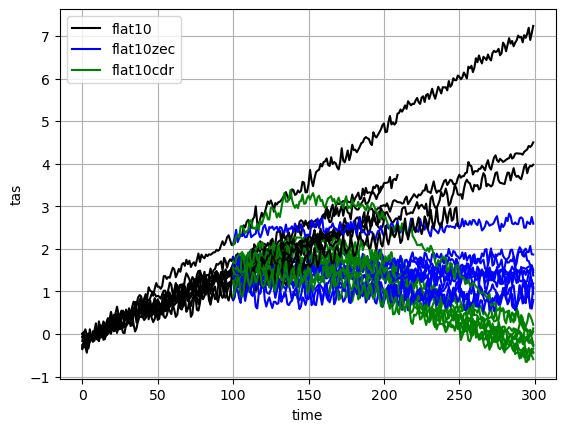

In [5]:
t_anom = tas_ts_datarray['tas'] - tas_ts_datarray['tas'] .isel(exp=0).isel(time=slice(0,20)).mean(dim='time')

#, linestyle=dashpattern_list[i], label=model)

for i, model in enumerate(models_list):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    t_anom.isel(exp=0).isel(model=i).plot(x='time', c='black', label=annotation_flat10)
    t_anom.isel(exp=1).isel(model=i).plot(x='time', c='blue', label=annotation_flat10zec)
    t_anom.isel(exp=2).isel(model=i).plot(x='time', c='green', label=annotation_flat10cdr)
plt.legend()
plt.title('')
plt.grid()


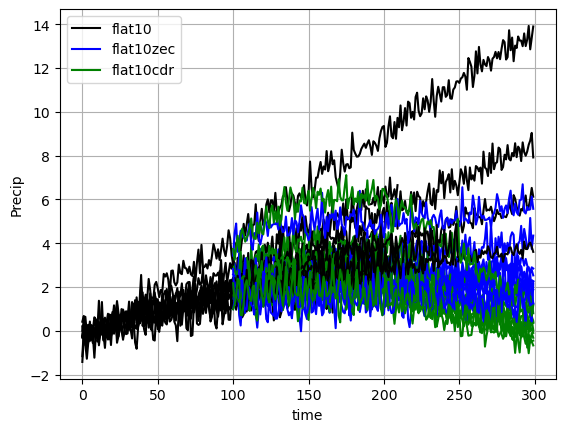

In [6]:
#p_percentchange = precip_ts_datarray['Precip'] / precip_ts_datarray['Precip'].isel(exp=0).isel(time=slice(0,20)).mean(dim='time')
p_percentchange = 100.*(precip_ts_datarray['Precip'] / precip_ts_datarray['Precip'].isel(exp=0).isel(time=slice(0,20)).mean(dim='time') - 1.)

for i in range(nmodels):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    p_percentchange.isel(exp=0).isel(model=i).plot(x='time', c='black', label=annotation_flat10)
    p_percentchange.isel(exp=1).isel(model=i).plot(x='time', c='blue', label=annotation_flat10zec)
    p_percentchange.isel(exp=2).isel(model=i).plot(x='time', c='green', label=annotation_flat10cdr)
    
plt.legend()
plt.title('')
plt.grid()


In [7]:
t_anom[0:100,1,:] = t_anom[0:100,0,:]
t_anom[0:100,2,:] = t_anom[0:100,0,:]

p_percentchange[0:100,1,:] = p_percentchange[0:100,0,:]
p_percentchange[0:100,2,:] = p_percentchange[0:100,0,:]

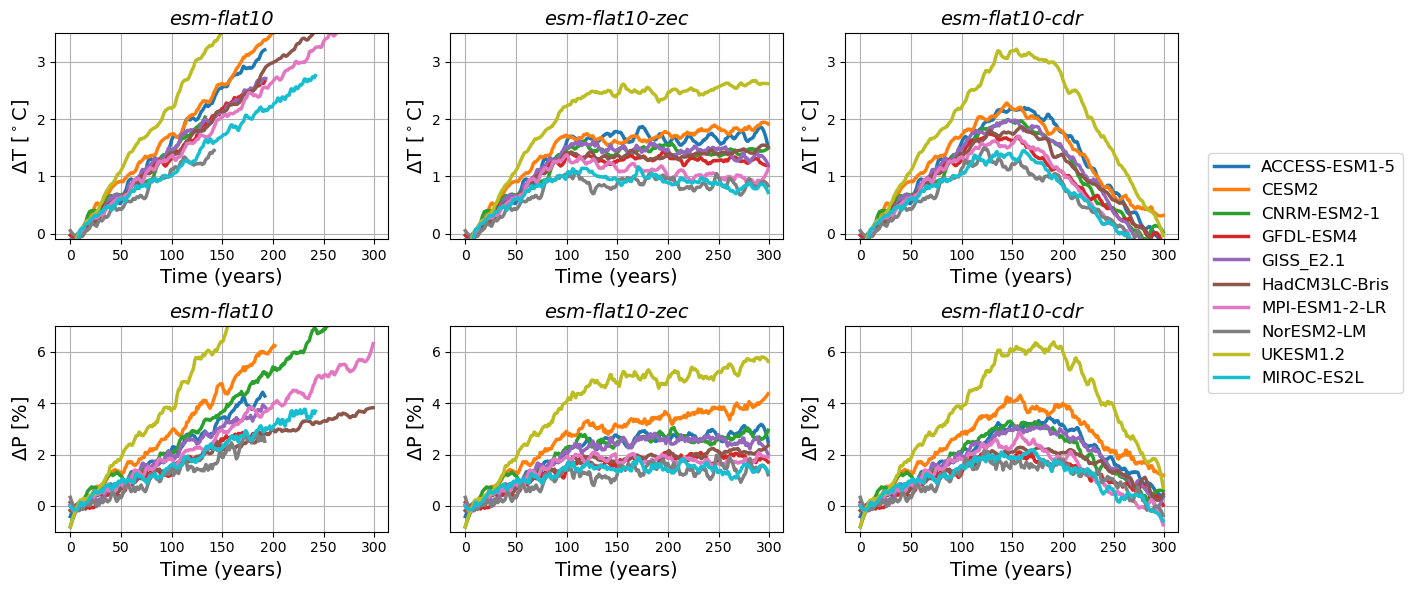

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

filter_window = 15
axs_flat = axs.flatten()

#color_list_models = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#56B4E9', '#E69F00','#999999', '#000000']

# Accessing the discrete colormap
cmap = plt.get_cmap('tab10')
#cmap = plt.get_cmap('Petroff10')
color_list_models = [cmap(i) for i in range(10)]

lw = 2.5

for i, model in enumerate(models_list):
    savgol_filter(t_anom.isel(exp=0).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], label=model, ax=axs_flat[0], lw=lw)
    savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], ax=axs_flat[1], lw=lw)
    savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], ax=axs_flat[2], lw=lw)
    #
    savgol_filter(p_percentchange.isel(exp=0).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], ax=axs_flat[3], lw=lw)
    savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], ax=axs_flat[4], lw=lw)
    savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window).plot(x='time', c=color_list_models[i], ax=axs_flat[5], lw=lw)
    
#axs_flat[0].legend(loc='upper left', fontsize=8)

axs_flat[0].set_title('esm-flat10', size=14, style='italic')
axs_flat[1].set_title('esm-flat10-zec', size=14, style='italic')
axs_flat[2].set_title('esm-flat10-cdr', size=14, style='italic')
axs_flat[3].set_title('esm-flat10', size=14, style='italic')
axs_flat[4].set_title('esm-flat10-zec', size=14, style='italic')
axs_flat[5].set_title('esm-flat10-cdr', size=14, style='italic')

axs_flat[0].set_ylabel('$\Delta$T [$^\circ$C]', size=14)
axs_flat[1].set_ylabel('$\Delta$T [$^\circ$C]', size=14)
axs_flat[2].set_ylabel('$\Delta$T [$^\circ$C]', size=14)
axs_flat[3].set_ylabel('$\Delta$P [%]', size=14)
axs_flat[4].set_ylabel('$\Delta$P [%]', size=14)
axs_flat[5].set_ylabel('$\Delta$P [%]', size=14)
for i in range(6):
    axs_flat[i].grid()
    axs_flat[i].set_xlabel('Time (years)', size=14)

for i in range(3):
    axs_flat[i].set_ylim(-0.1,3.5)

for i in range(3,6):
    axs_flat[i].set_ylim(-1,7)

handles, labels = axs_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.18, 0.75), fontsize=12, markerscale=13)

plt.tight_layout()
#plt.show()

plt.savefig('fig_temp_precip_timeseries', dpi=300, bbox_inches='tight')

(-5.0, 5.0)

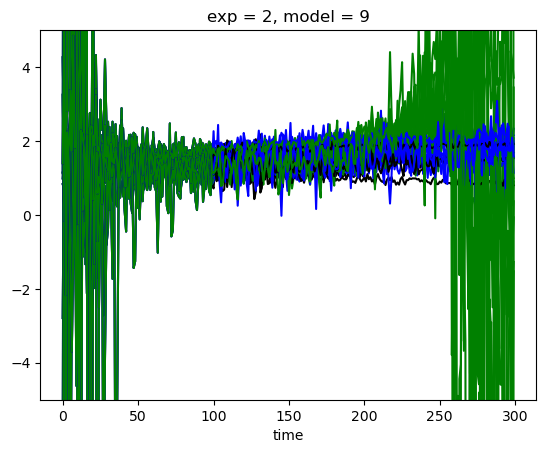

In [9]:
p_percentchange_perdegree = p_percentchange / t_anom

for i in range(nmodels):
    p_percentchange_perdegree.isel(exp=0).isel(model=i).plot(x='time', c='black')
    p_percentchange_perdegree.isel(exp=1).isel(model=i).plot(x='time', c='blue')
    p_percentchange_perdegree.isel(exp=2).isel(model=i).plot(x='time', c='green')

plt.ylim(-5,5)

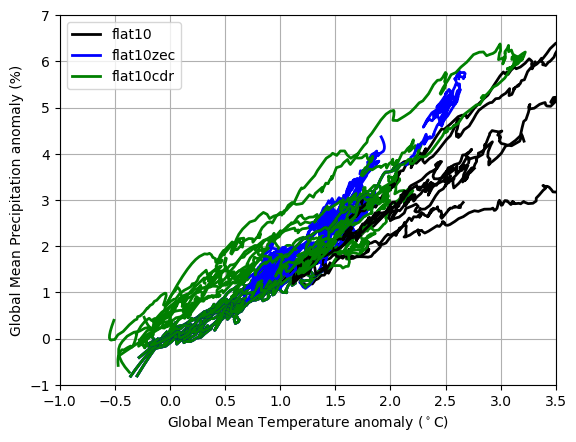

In [10]:
filter_window = 15

for i in range(nmodels):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    plt.plot(savgol_filter(t_anom.isel(exp=0).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=0).isel(model=i), filter_window), c='black', linewidth=2, label=annotation_flat10)
    plt.plot(savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window), c='blue', linewidth=2, label=annotation_flat10zec)
    plt.plot(savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window), c='green', linewidth=2, label=annotation_flat10cdr)
    
plt.xlabel('Global Mean Temperature anomaly ($^\circ$C)')
plt.ylabel('Global Mean Precipitation anomaly (%)')
plt.xlim(-1,3.5)
plt.ylim(-1,7)
plt.grid()
plt.legend()

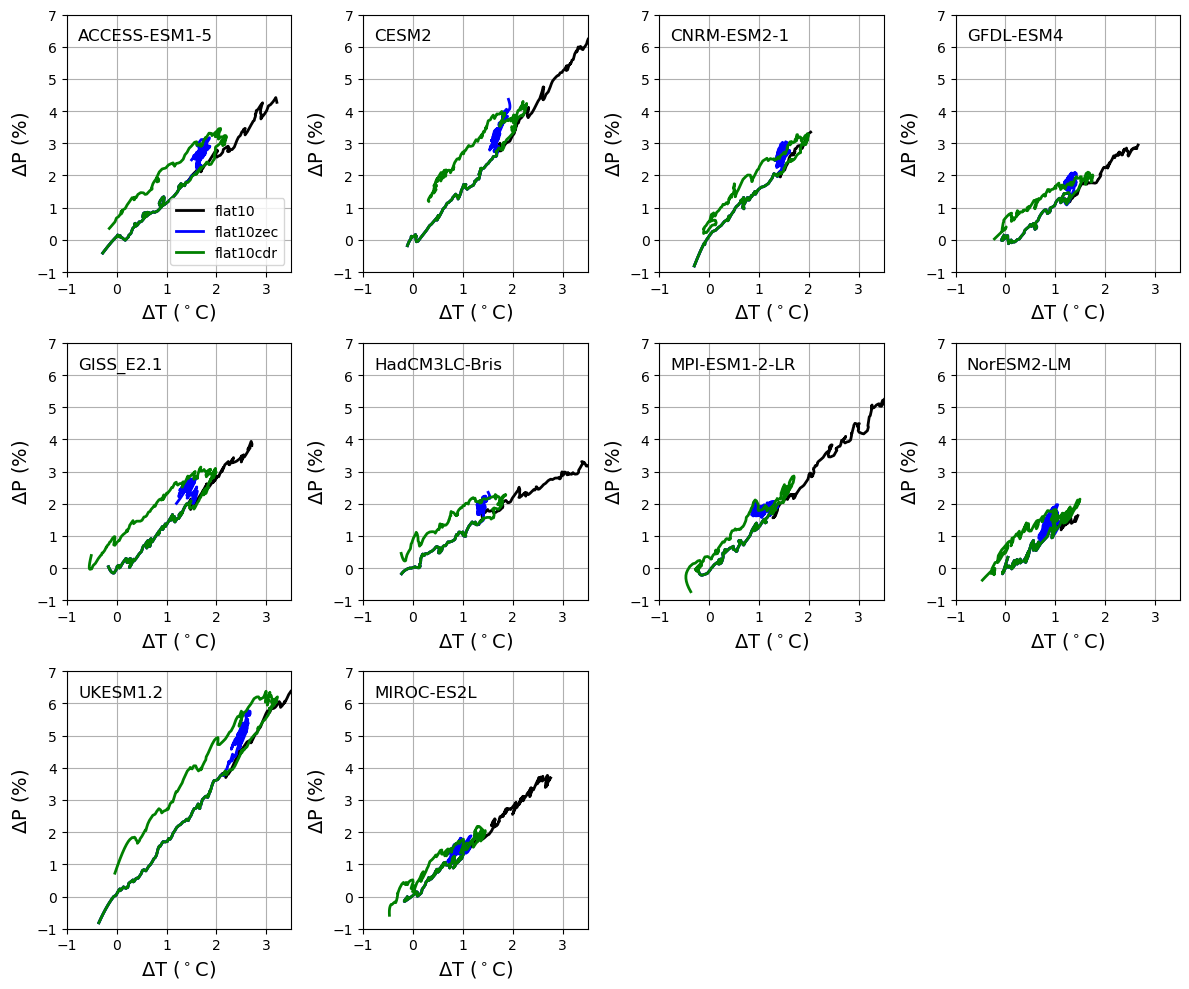

In [11]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))

filter_window = 15
axs_flat = axs.flatten()

for i in range(nmodels):
    model = models_list[i]
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=0).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=0).isel(model=i), filter_window), c='black', linewidth=2, label=annotation_flat10)
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window), c='blue', linewidth=2, label=annotation_flat10zec)
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window), c='green', linewidth=2, label=annotation_flat10cdr)
    #
    axs_flat[i].set_xlabel('$\Delta$T ($^\circ$C)', fontsize=14)
    axs_flat[i].set_ylabel('$\Delta$P (%)', fontsize=14)
    axs_flat[i].set_xlim(-1,3.5)
    axs_flat[i].set_ylim(-1,7)
    axs_flat[i].grid()
    if i == 0:
        axs_flat[i].legend(loc='lower right')
    axs_flat[i].annotate(model, xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12)

axs_flat[nmodels].axis('off')
axs_flat[nmodels+1].axis('off')

plt.tight_layout()


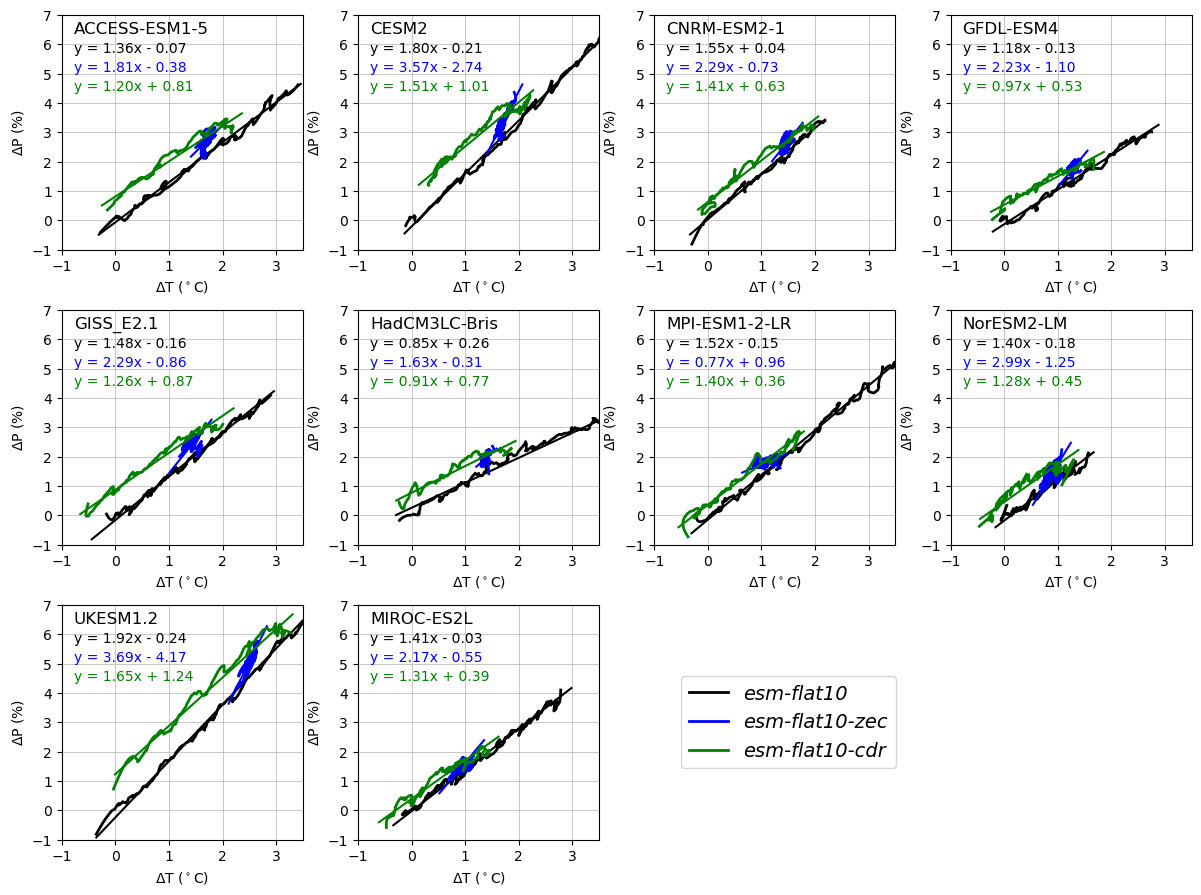

In [12]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))

filter_window = 15
axs_flat = axs.flatten()

colorlist = ['black','blue','green']
t_anom_masked = t_anom.copy()
p_percentchange_masked = p_percentchange.copy()

t_anom_masked[0:100,1,:] = np.nan
p_percentchange_masked[0:100,1,:] = np.nan

t_anom_masked[0:150,2,:] = np.nan
p_percentchange_masked[0:150,2,:] = np.nan

vert_coords_text = [0.84,0.76,0.68]

slopes = [[],[],[]]
offsets = [[],[],[]]
for i in range(nmodels):
    model = models_list[i]
    if i == 9:
        annotations = ['esm-flat10','esm-flat10-zec','esm-flat10-cdr']
    else:
        annotations = [None,None,None]
    for exp_i in range(3):
        x_smooth = savgol_filter(t_anom_masked.isel(exp=exp_i).isel(model=i).dropna(dim='time'), filter_window)
        y_smooth = savgol_filter(p_percentchange_masked.isel(exp=exp_i).isel(model=i).dropna(dim='time'), filter_window)
        x = t_anom_masked.isel(exp=exp_i).isel(model=i).dropna(dim='time')
        y = p_percentchange_masked.isel(exp=exp_i).isel(model=i).dropna(dim='time')
        try:
            b, a = np.polyfit(x, y, deg=1)
        except:
            minlength = min(len(x),len(y))
            x = x[0:minlength]
            y = y[0:minlength]
            x_smooth = x_smooth[0:minlength]
            y_smooth = y_smooth[0:minlength]
            b, a = np.polyfit(x, y, deg=1)
        slopes[exp_i].append(b)
        offsets[exp_i].append(a)
        xseq = np.linspace(x.min(), x.max(), num=100)
        axs_flat[i].plot(xseq, a + b * xseq, color=colorlist[exp_i], lw=1.5)
        annotation_text_regress = f"y = {b:.2f}x {'+' if a >= 0 else '-'} {abs(a):.2f}"
        axs_flat[i].annotate(annotation_text_regress, xy=(0.05, vert_coords_text[exp_i]), xycoords='axes fraction', fontsize=10, c=colorlist[exp_i])
        axs_flat[i].plot(x_smooth, y_smooth, c=colorlist[exp_i], linewidth=2, label=annotations[exp_i])
    #axs_flat[i].plot(savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window), c='blue', linewidth=2, label=annotation_flat10zec)
    #axs_flat[i].plot(savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window), c='green', linewidth=2, label=annotation_flat10cdr)
    #
    axs_flat[i].set_xlabel('$\Delta$T ($^\circ$C)')
    axs_flat[i].set_ylabel('$\Delta$P (%)')
    axs_flat[i].set_xlim(-1,3.5)
    axs_flat[i].set_ylim(-1,7)
    axs_flat[i].grid(linewidth=0.5)
    if i == 9:
        legend = axs_flat[i].legend(loc='center left', bbox_to_anchor=(1.3, 0.5), prop={'style': 'italic', 'size': 14})
        legend.set_in_layout(False)
    axs_flat[i].annotate(model, xy=(0.05, 0.92), xycoords='axes fraction', fontsize=12)

axs_flat[nmodels].axis('off')
axs_flat[nmodels+1].axis('off')

plt.tight_layout()
plt.savefig('fig_temp_vs_precip_traces', dpi=300, bbox_inches='tight')

In [13]:
min(len(x),len(y))

150

In [14]:
print(np.median(slopes[0]))
print(np.median(slopes[1]))
print(np.median(slopes[2]))
print()
print(np.median(offsets[0]))
print(np.median(offsets[1]))
print(np.median(offsets[2]))

1.4454920952194457
2.2618633431520943
1.2928534419134463

-0.13879280437570218
-0.792990320821689
0.699497306453202


In [15]:
time = np.arange(300)
flat10_emiss = np.ones(300)*10.

flat10zec_emiss = np.ones(300)*10.
flat10zec_emiss[100:] = 0.

flat10cdr_emiss = np.ones(300)*10.
flat10cdr_emiss[100:200] = 10. - np.arange(100)*0.2
flat10cdr_emiss[200:] = -10

flat10_cumemiss = flat10_emiss.cumsum()
flat10zec_cumemiss = flat10zec_emiss.cumsum()
flat10cdr_cumemiss = flat10cdr_emiss.cumsum()

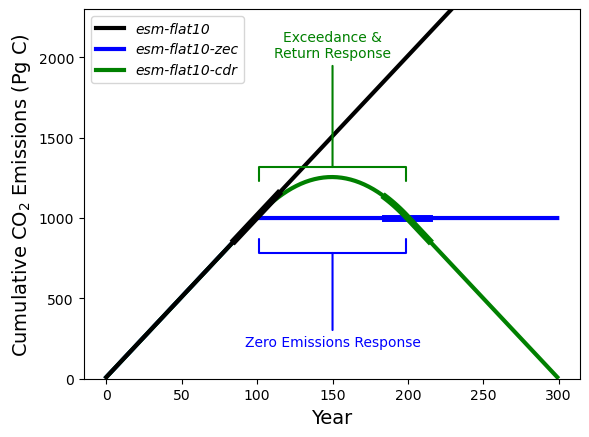

In [16]:
width1=3
width2=5

plt.plot(time, flat10_cumemiss, color='black', label='esm-flat10', lw=width1, zorder=3)
plt.plot(time, flat10zec_cumemiss, color='blue', label='esm-flat10-zec', lw=width1)
plt.plot(time, flat10cdr_cumemiss, color='green', label='esm-flat10-cdr', lw=width1)

plt.plot(time[85:115], flat10_cumemiss[85:115], color='black', lw=width2, zorder=3)
plt.plot(time[185:215], flat10zec_cumemiss[185:215], color='blue', lw=width2)
plt.plot(time[185:215], flat10cdr_cumemiss[185:215], color='green', lw=width2)

plt.annotate('Zero Emissions Response', xy=(150, 800), xytext=(150, 200),
            arrowprops=dict(arrowstyle='-[, widthB=5.3, lengthB=1.0', lw=1.5, color='blue'), horizontalalignment='center',color='blue')
plt.annotate('Exceedance &\nReturn Response', xy=(150, 1300), xytext=(150, 2000),
            arrowprops=dict(arrowstyle='-[, widthB=5.3, lengthB=1.0', lw=1.5, color='green'), horizontalalignment='center',color='green')
plt.ylim(0,2300)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Cumulative CO$_2$ Emissions (Pg C)', fontsize=14)
#plt.ylabel('Cumulative CO$_2$ Emissions \n and Expected Temperature Response')
plt.legend(prop={'style': 'italic'})
#plt.tick_params(left=False, labelleft=False)
plt.savefig('fig_experiment_schematic.png', dpi=300, bbox_inches='tight')


In [17]:
flat10cdr_cumemiss[185:215].mean()


1001.2666666666667

In [18]:
flat10zec_cumemiss[185:215].mean()


1000.0

In [19]:
flat10_cumemiss[85:115].mean()

1005.0